In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import time

print("Загружаем MNIST...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
print(f"Форма данных: {X.shape}, метки: {y.shape}")

Загружаем MNIST...
Форма данных: (70000, 784), метки: (70000,)


In [18]:
y = y.astype(int)

# 10 000 примеров
n_samples = 10000
X = X[:n_samples]
y = y[:n_samples]

# Разбитие на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}, тестовая: {X_test.shape}")

# Масштабирование картинок
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Данные отмасштабированы.")

Обучающая выборка: (8000, 784), тестовая: (2000, 784)
Данные отмасштабированы.


In [60]:
print("Создаём нейронную сеть...")
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),   # два скрытых слоя: 100 и 50 нейронов
    activation='relu',             # активация ReLU
    solver='adam',                 # оптимизатор Adam
    max_iter=50,                   # количество эпох (поколения тип)
    random_state=42,
    verbose=True                   # эт мы будем видеть прогресс обучения
)

print("Запуск обучения...")
start_time = time.time()
mlp.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Обучение завершено за {train_time:.2f} секунд")

Создаём нейронную сеть...
Запуск обучения...
Iteration 1, loss = 1.15985848
Iteration 2, loss = 0.35364297
Iteration 3, loss = 0.21648964
Iteration 4, loss = 0.15473523
Iteration 5, loss = 0.11575880
Iteration 6, loss = 0.08726895
Iteration 7, loss = 0.06766652
Iteration 8, loss = 0.05236762
Iteration 9, loss = 0.04076605
Iteration 10, loss = 0.03203527
Iteration 11, loss = 0.02556644
Iteration 12, loss = 0.02019627
Iteration 13, loss = 0.01622216
Iteration 14, loss = 0.01320720
Iteration 15, loss = 0.01093586
Iteration 16, loss = 0.00886582
Iteration 17, loss = 0.00756479
Iteration 18, loss = 0.00632546
Iteration 19, loss = 0.00556490
Iteration 20, loss = 0.00483304
Iteration 21, loss = 0.00426541
Iteration 22, loss = 0.00371227
Iteration 23, loss = 0.00331422
Iteration 24, loss = 0.00299863
Iteration 25, loss = 0.00266618
Iteration 26, loss = 0.00247579
Iteration 27, loss = 0.00225452
Iteration 28, loss = 0.00205253
Iteration 29, loss = 0.00187830
Iteration 30, loss = 0.00175512
Iter

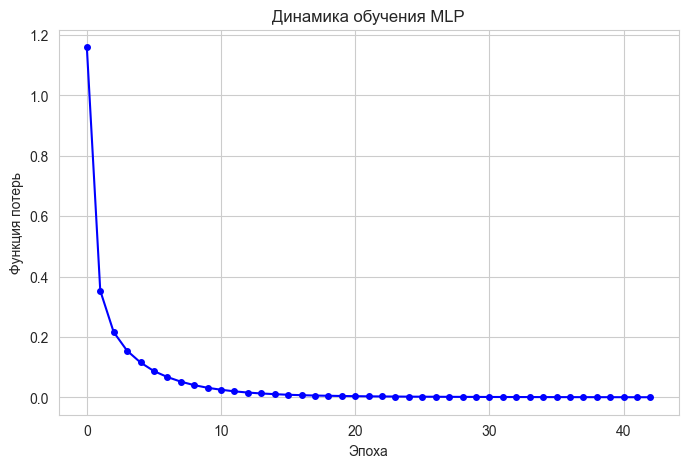

In [61]:
# График обучения (кривая потерь)
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, 'b-o', markersize=4)
plt.title("Динамика обучения MLP")
plt.xlabel("Эпоха")
plt.ylabel("Функция потерь")
plt.grid(True)
plt.show()

Точность на тестовой выборке: 0.9390


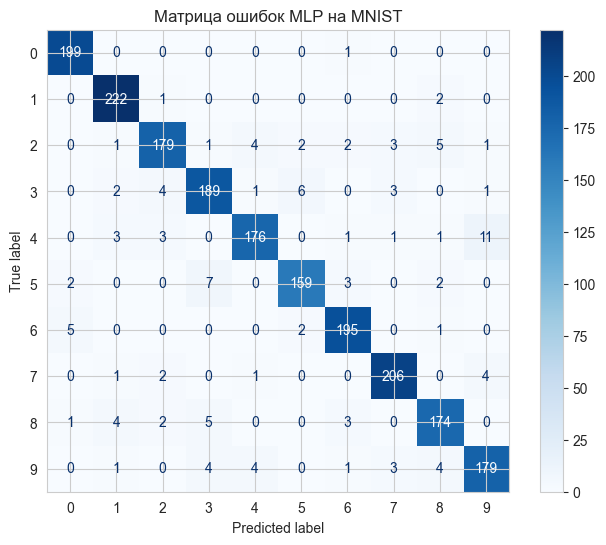

In [62]:
# Предсказание сетки
y_pred = mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Матрица ошибок MLP на MNIST")
plt.show()

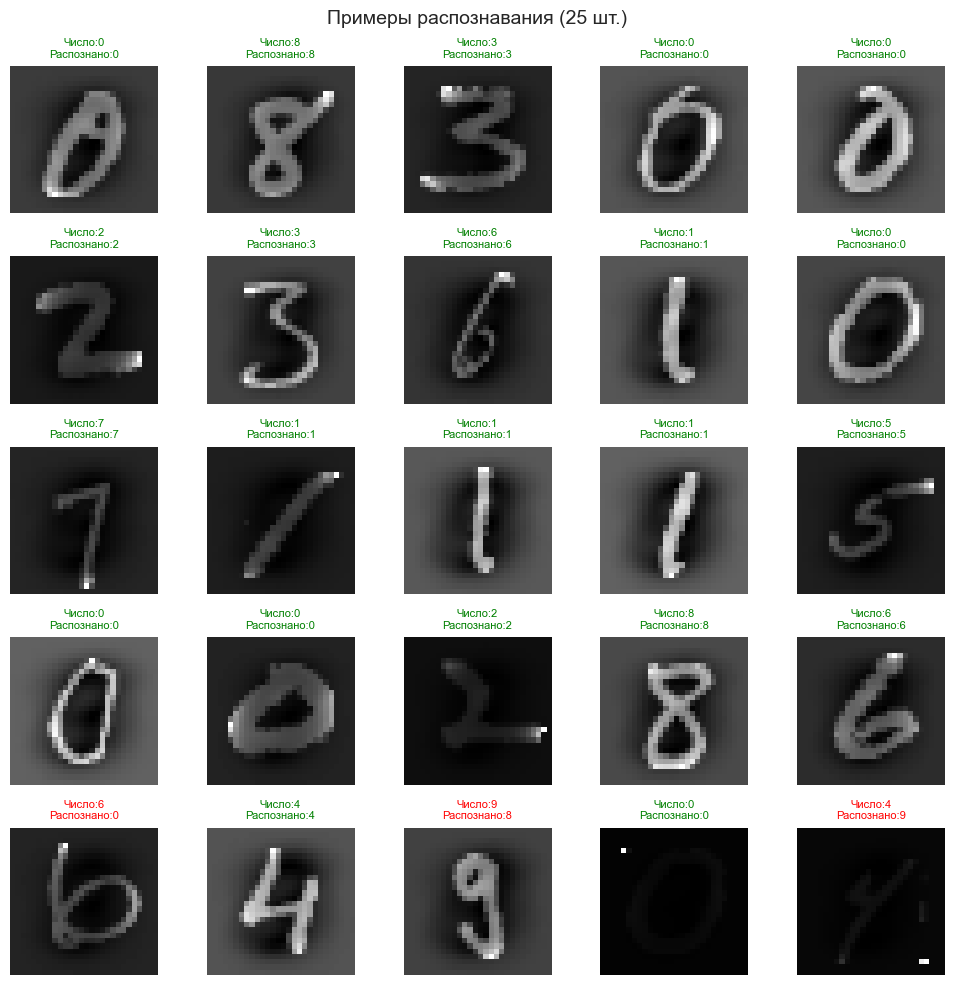

In [63]:

import math
n_images = 25  # сколь картинок
n_cols = 5     # сколь картинок в строке
n_rows = math.ceil(n_images / n_cols)
indices = np.random.choice(len(X_test), n_images, replace=False)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
axes = axes.flatten()  # превращение в одномерный массив

for i, idx in enumerate(indices):
    img = X_test[idx].reshape(28, 28)
    true_label = y_test[idx]
    pred_label = y_pred[idx]

    axes[i].imshow(img, cmap='gray')
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"Число:{true_label}\nРаспознано:{pred_label}", color=color, fontsize=8)
    axes[i].axis('off')

# минус лишние оси, если картинок мало
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"Примеры распознавания ({n_images} шт.)", fontsize=14)
plt.tight_layout()
plt.show()